# Day 19 — Resume-JD Matcher (Deep Neural Network)

Siamese BiLSTM model that reads a resume and a job description and predicts
**Weak / Medium / Strong** match.

Run this top to bottom. If you're in Colab, upload `train.jsonl` first (or mount Drive)
and update `DATA_PATH` below.

In [5]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print(tf.__version__)

2.20.0


## 1. Load the dataset

In [6]:
DATA_PATH = "/content/train.jsonl"

df = pd.read_json(DATA_PATH, lines=True)
print(df.shape)
df.head()

(50000, 7)


,Job-Description,Resume-matched,Resume-unmatched,Skills,Experiences,Experiences-years,Filtered-information
0,\n\n## Job Title\nOracle SCM Developer\n\n## J...,\n\n## Personal Information\nName: Konstantina...,\n\n## Personal Information\nName: Konstantina...,"[SQL, ERP, Supply chain, BOM, WIP]","[Oracle SCM Developer, SAP Sales and Supply Ch...","[[[3 years as a Oracle SCM Developer, 1 years ...","{'Skills': ['ERP', 'BOM', 'SQL'], 'Experience'..."
1,"\n\n## Job Title\nElectrical, Electronic, and ...",\n\n## Personal Information\nName: Yelena Belo...,\n\n## Personal Information\nName: Yelena Belo...,"[Medical Knowledge, Technical Skills, Problem-...","[Electrical, electronic, and electromechanical...",[[[4 years as a Electrical - electronic - and ...,"{'Skills': ['Interpersonal Skills', 'Technical..."
2,\n\n## Job Title\nUI - Sr. Java Tech Lead (Por...,\n\n## Personal Information\nName: Matthew Ste...,\n\n## Personal Information\nName: Matthew Jam...,"[ASP. NET, HTML, HTML DOM, Java, Java Service ...",[UI - Sr. Java Tech Lead (Portals) & Sr. UI Ja...,[[[4 years as a UI - Sr. Java Tech Lead (Porta...,"{'Skills': ['Microsoft .NET Framework', 'Java ..."
3,\n\n## Job title\nTechnical Architect- JAVA\n\...,\n\n## Personal Information\nName: Haruna Yaku...,\n\n## Personal Information\nName: Haruna Yaku...,"[JAVA, J2EE, Architect, SOA, Spring MVC, Model...",[Technical Architect- JAVA],"[[[3 years as a Technical Architect- JAVA], [T...","{'Skills': ['web services', 'JAVA', 'J2EE'], '..."
4,\n\n## Job title\nFishing and Hunting Worker\n...,\n\n## Personal Information\nName: Finley Murr...,\n\n## Personal Information\nName: Finley Murr...,"[Emergency Response, Physical Fitness and Stam...","[Fishing and hunting workers, Forest fire insp...","[[[4 years as a Fishing and hunting workers, 2...","{'Skills': ['Emergency Response', 'Incident Co..."


## 2. Build resume-JD pairs


In [7]:
positive = pd.DataFrame({
    "resume": df["Resume-matched"],
    "jd": df["Job-Description"],
    "label": 2
})

negative = pd.DataFrame({
    "resume": df["Resume-unmatched"],
    "jd": df["Job-Description"],
    "label": 0
})

data = pd.concat([positive, negative], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(data.shape)
data["label"].value_counts()

(100000, 3)


,count
label,
0,50000
2,50000


## 3. Clean the text

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["resume"] = data["resume"].apply(clean_text)
data["jd"] = data["jd"].apply(clean_text)

data.head()

,resume,jd,label
0,personal information name leano dalton email l...,job title network engineer fulltime relo job s...,0
1,personal information name eun woo park email e...,job title graphic designer job summary we are ...,0
2,personal information name vasileios papadopoul...,job title senior exchange engineer job summary...,2
3,personal information name gunel smith email gu...,job title business analyst associate sf or ran...,0
4,personal information name aminata jacobs email...,job title production engineer technical suppor...,0


## 4. Tokenize and pad

In [9]:
MAX_WORDS = 20000
MAX_LEN = 200

Tokenizer = keras.preprocessing.text.Tokenizer
pad_sequences = keras.preprocessing.sequence.pad_sequences

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(data["resume"].tolist() + data["jd"].tolist())

resume_seq = pad_sequences(tokenizer.texts_to_sequences(data["resume"]), maxlen=MAX_LEN)
jd_seq = pad_sequences(tokenizer.texts_to_sequences(data["jd"]), maxlen=MAX_LEN)
labels = data["label"].values

resume_seq.shape, jd_seq.shape, labels.shape

((100000, 200), (100000, 200), (100000,))

## 5. Train/test split

In [10]:
X_resume_train, X_resume_test, X_jd_train, X_jd_test, y_train, y_test = train_test_split(
    resume_seq, jd_seq, labels, test_size=0.2, random_state=42
)

X_resume_train.shape, X_resume_test.shape

((80000, 200), (20000, 200))

## 6. Build the Siamese BiLSTM model
Then a small dense classifier turns that comparison into Weak / Medium / Strong.

In [11]:
EMBEDDING_DIM = 128
LSTM_UNITS = 64

resume_input = keras.layers.Input(shape=(MAX_LEN,), name="resume_input")
jd_input = keras.layers.Input(shape=(MAX_LEN,), name="jd_input")

embedding = keras.layers.Embedding(MAX_WORDS, EMBEDDING_DIM)
bilstm = keras.layers.Bidirectional(keras.layers.LSTM(LSTM_UNITS, return_sequences=True))
pooling = keras.layers.GlobalMaxPooling1D()

def encode(x):
    x = embedding(x)
    x = bilstm(x)
    x = pooling(x)
    return x

resume_vec = encode(resume_input)
jd_vec = encode(jd_input)

diff = keras.layers.Lambda(lambda t: tf.abs(t[0] - t[1]))([resume_vec, jd_vec])
prod = keras.layers.Multiply()([resume_vec, jd_vec])
sim = keras.layers.Dot(axes=1, normalize=True)([resume_vec, jd_vec])

merged = keras.layers.Concatenate()([resume_vec, jd_vec, diff, prod, sim])

x = keras.layers.Dense(128, activation="relu")(merged)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation="relu")(x)
output = keras.layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs=[resume_input, jd_input], outputs=output)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resume_input        │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jd_input            │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  2,560,000 │ resume_input[0][… │
│ (Embedding)         │                   │            │ jd_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 200, 128)  │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │ bidirectional[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128)       │          0 │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 513)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ lambda[0][0],     │
│                     │                   │            │ multiply[0][0],   │
│                     │                   │            │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,733,059 (10.43 MB)

 Trainable params: 2,733,059 (10.43 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train

In [12]:
history = model.fit(
    [X_resume_train, X_jd_train],
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 79s 35ms/step - accuracy: 0.6730 - loss: 0.6009 - val_accuracy: 0.7013 - val_loss: 0.5747
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.7812 - loss: 0.4676 - val_accuracy: 0.7501 - val_loss: 0.5133
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.8392 - loss: 0.3692 - val_accuracy: 0.7465 - val_loss: 0.5156
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.8829 - loss: 0.2825 - val_accuracy: 0.7317 - val_loss: 0.6313
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 71s 36ms/step - accuracy: 0.9157 - loss: 0.2094 - val_accuracy: 0.7322 - val_loss: 0.7029
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.9398 - loss: 0.1529 - val_accuracy: 0.7281 - val_loss: 0.8026
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.9542 - loss: 0.1197 - val_accuracy: 0.7230 - val_loss: 0.8299
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.9633 -

## 8. Evaluate

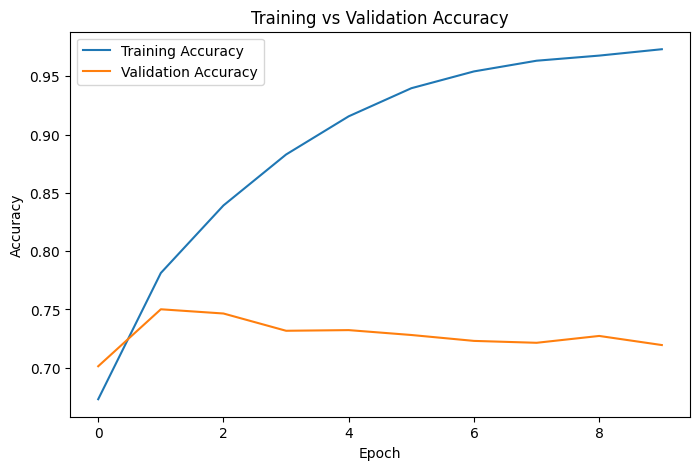

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [14]:
test_loss, test_acc = model.evaluate([X_resume_test, X_jd_test], y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

preds = model.predict([X_resume_test, X_jd_test])
pred_classes = preds.argmax(axis=1)

print(classification_report(y_test, pred_classes))

625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7218 - loss: 1.2489
Test Accuracy: 0.7218000292778015
Test Loss: 1.248863935470581
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step
              precision    recall  f1-score   support

           0       0.74      0.69      0.71     10078
           2       0.71      0.76      0.73      9922

    accuracy                           0.72     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.72      0.72      0.72     20000



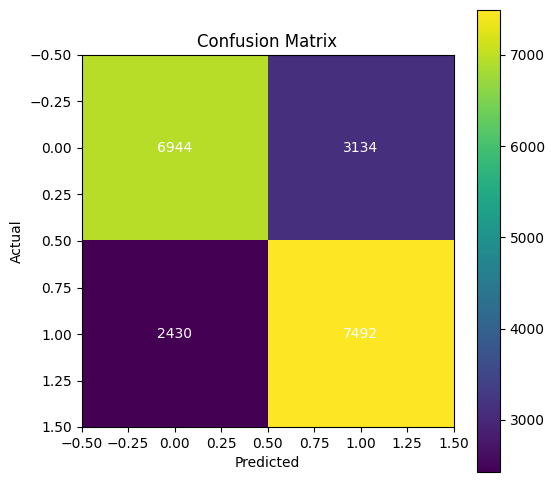

In [15]:
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white")
plt.show()

## 9. Predict on a new resume/JD pair

In [16]:
LABELS = {0: "Weak Match", 1: "Medium Match", 2: "Strong Match"}

def predict_match(resume_text, jd_text):
    resume_clean = clean_text(resume_text)
    jd_clean = clean_text(jd_text)

    resume_s = pad_sequences(tokenizer.texts_to_sequences([resume_clean]), maxlen=MAX_LEN)
    jd_s = pad_sequences(tokenizer.texts_to_sequences([jd_clean]), maxlen=MAX_LEN)

    probs = model.predict([resume_s, jd_s])[0]
    predicted_class = int(np.argmax(probs))
    match_score = float(np.max(probs) * 100)

    return LABELS[predicted_class], match_score, probs

sample_resume = "5 years experience in python, sql and machine learning"
sample_jd = "looking for a python developer with sql and ml skills"

category, score, probs = predict_match(sample_resume, sample_jd)
print("Match Category:", category)
print(f"Match Score: {score:.2f}%")
print("Probabilities:", probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
Match Category: Weak Match
Match Score: 100.00%
Probabilities: [9.999628e-01 0.000000e+00 3.715962e-05]


## 10. Skill overlap report (simple, keyword-based)

Not part of the DNN — just a quick rule-based add-on so the output feels like
a real ATS report: which skills overlap, which are missing.

In [17]:
COMMON_SKILLS = [
    "python", "sql", "java", "aws", "docker", "kubernetes",
    "machine learning", "deep learning", "nlp", "excel",
    "power bi", "tableau", "git", "linux", "c++", "javascript"
]

def extract_skills(text):
    text = text.lower()
    return {skill for skill in COMMON_SKILLS if skill in text}

resume_skills = extract_skills(sample_resume)
jd_skills = extract_skills(sample_jd)

common = resume_skills & jd_skills
missing = jd_skills - resume_skills

print("Common Skills:", sorted(common))
print("Missing Skills:", sorted(missing))

Common Skills: ['python', 'sql']
Missing Skills: []


## 11. Save the model

In [18]:
import os
os.makedirs("models", exist_ok=True)
model.save("models/resume_jd_matcher.keras")
print("Saved to models/resume_jd_matcher.keras")

Saved to models/resume_jd_matcher.keras
